In [3]:
# Import the python packages. Rerun this code again if there is you encounter an error on xarray_schema.
import scanpy as sc
import pandas as pd
import numpy as np
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import os
import squidpy as sq
import spatialdata as sd
import spatialdata_io as sio
from pathlib import Path

In [4]:
xeinum_path = Path("/g/stegle/aalsayah/repos/data/xenium")

In [13]:
sdata = sd.read_zarr(xeinum_path / "cell_features/")

In [15]:
sdata = sio.xenium( xeinum_path / "Xenium_Prime_Human_Skin_FFPE_outs/")

INFO     reading /g/stegle/aalsayah/repos/data/xenium/Xenium_Prime_Human_Skin_FFPE_outs/cell_feature_matrix.h5     


/scratch/jobs/38286859/ipykernel_4135236/1976238057.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = sio.xenium( xeinum_path / "Xenium_Prime_Human_Skin_FFPE_outs/")
/home/alsayah/.local/lib/python3.10/site-packages/spatialdata_io/_utils.py:48: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/home/alsayah/.local/lib/python3.10/site-packages/spatialdata_io/_utils.py:48: UserWarning: The cell_id column in the cell_labels_table does not match the cell_id column derived from the cell labels data. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)


In [16]:
sdata

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 20294, 42748), (4, 10147, 21374), (4, 5073, 10687), (4, 2536, 5343), (4, 1268, 2671)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
│     └── 'nucleus_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (112551, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (112551, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (109795, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (112551, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (S

In [17]:
del sdata['morphology_focus']

In [18]:
sdata

SpatialData object
├── Labels
│     ├── 'cell_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
│     └── 'nucleus_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (112551, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (112551, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (109795, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (112551, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [19]:
sdata.write(xeinum_path / "Skin.zarr")

INFO     The Zarr backing store has been changed from None the new file path:                                      
         /g/stegle/aalsayah/repos/data/xenium/Skin.zarr                                                            


In [20]:
sdata = sd.read_zarr(xeinum_path / "Skin.zarr/")

/home/alsayah/.local/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [21]:
sdata

SpatialData object, with associated Zarr store: /g/stegle/aalsayah/repos/data/xenium/Skin.zarr
├── Labels
│     ├── 'cell_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
│     └── 'nucleus_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (112551, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (112551, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (109795, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (112551, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [23]:
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

/home/alsayah/.local/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


In [ ]:
# The x and y axis are pixel coordinates
sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

In [24]:
adata = sdata["table"]

In [25]:
adata

AnnData object with n_obs × n_vars = 112551 × 5006
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

Text(0, 0.5, 'Number of cells')

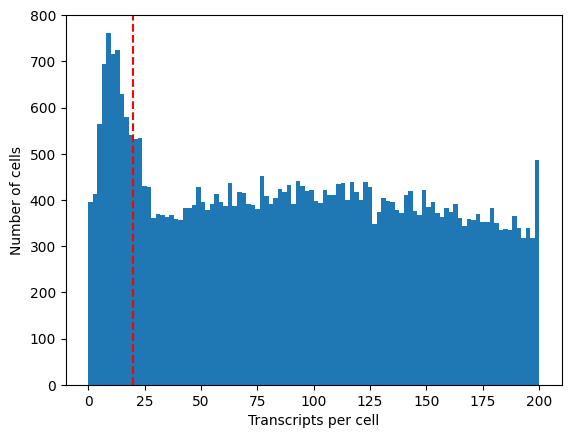

In [28]:
fig = plt.hist(adata.obs["total_counts"], range=(0, 200), bins=100)
plt.axvline(x=20, color="r", linestyle="--")  # You can customize color and linestyle

plt.xlabel("Transcripts per cell")
plt.ylabel("Number of cells")

In [29]:
# Based on the histogram plot, here we choose 20 transcript counts as lower cutoff
thres = np.quantile(adata.obs["total_counts"], 0.98)
sc.pp.filter_cells(adata, min_counts=20)
sc.pp.filter_cells(adata, max_counts=thres)

# We also filter out genes that are rarely expressed
sc.pp.filter_genes(adata, min_cells=100)

In [31]:
# Log Normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

In [32]:
sc.pp.scale(adata, zero_center=False, max_value=10)

In [33]:
%%time
# PCA for dimension reduction further by UMAP for downstream analysis
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, metric="cosine")
# clustering with leiden. We use igraph here as it scales better. The resolution is a hyper-parameter. A higher resolution will output more clusters.
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=0.5)

/g/easybuild/x86_64/Rocky/8/genoa/software/Miniforge3/24.1.2-0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 52.4 s, sys: 297 ms, total: 52.7 s
Wall time: 55.2 s


In [34]:
%%time
############### SKIP these steps for in-person events ###################
sc.tl.umap(adata)

CPU times: user 1min 24s, sys: 31.3 ms, total: 1min 24s
Wall time: 1min 19s


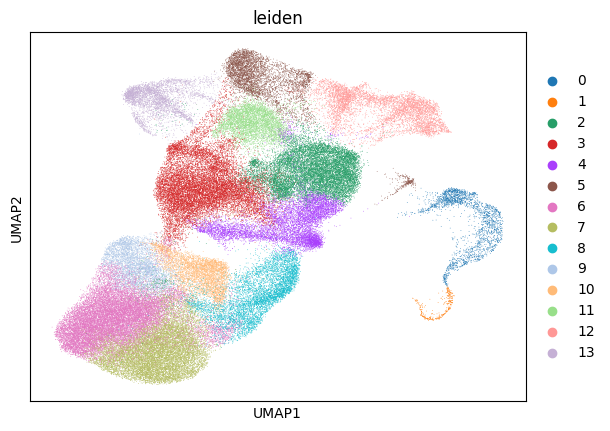

In [35]:
sc.pl.umap(adata, color="leiden")

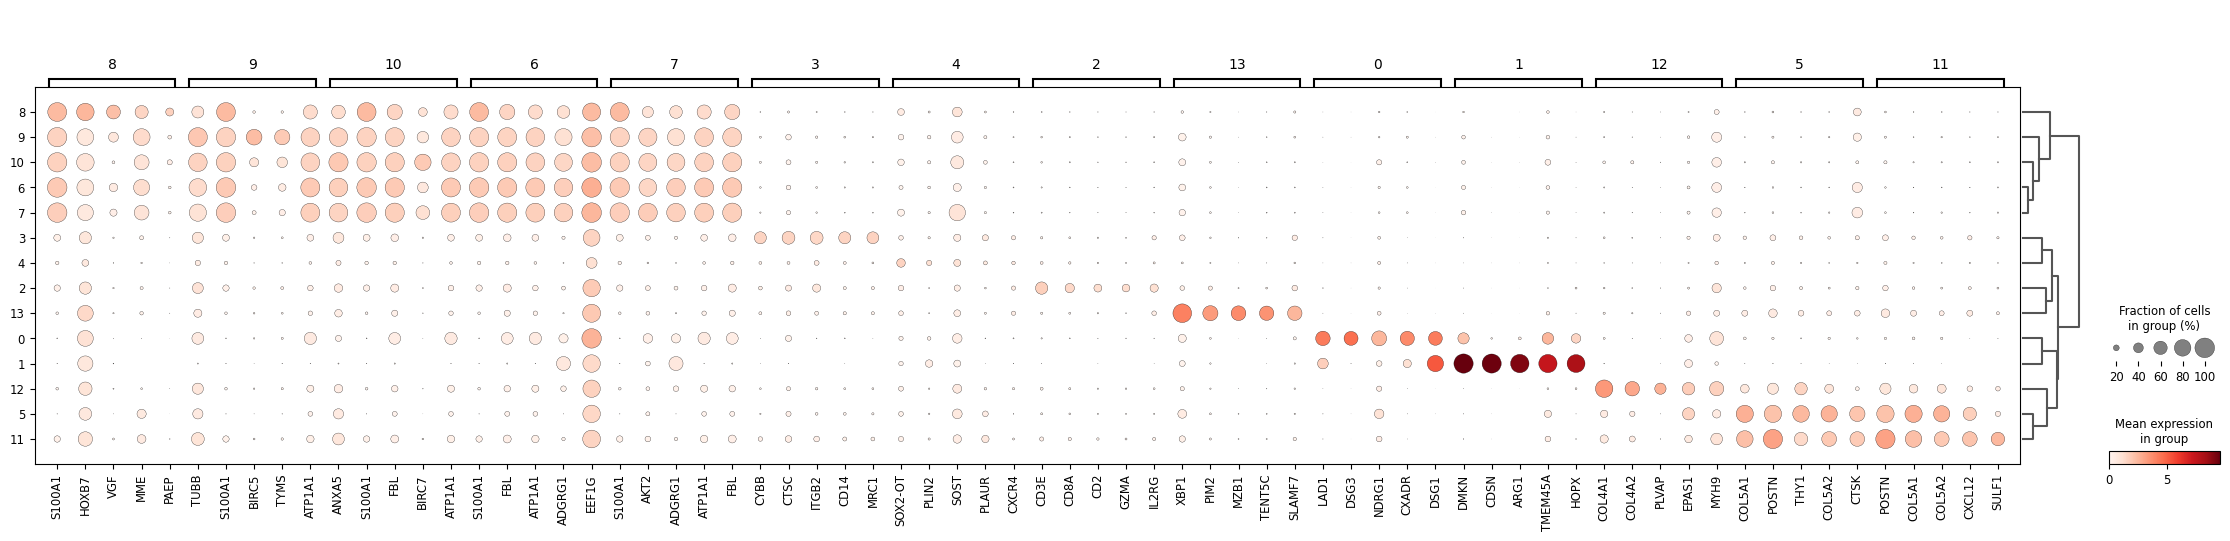

In [36]:
sc.tl.rank_genes_groups(adata, groupby="leiden", layer="lognorm", pts=True)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)

In [39]:
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

/home/alsayah/.local/lib/python3.10/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


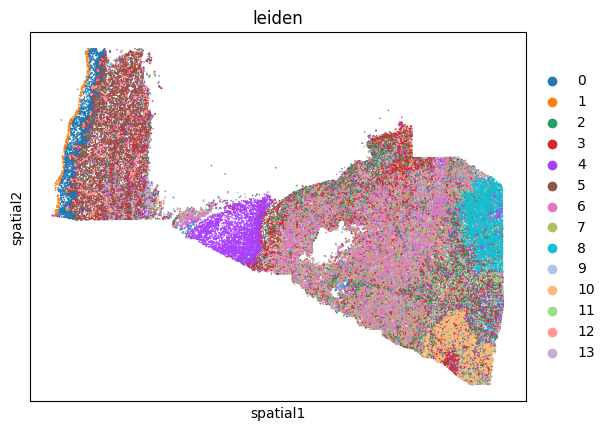

In [42]:
sc.pl.embedding(adata, basis="spatial", color="leiden", s=5)  # s = point size

In [43]:
adata

AnnData object with n_obs × n_vars = 104276 × 4278
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mean', 'std'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'rank_genes_groups', 'dendrogram_leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'lognorm'
    obsp: 'distances', 'connectivities'

In [44]:
adata.write_h5ad(xeinum_path / "skin_adata.h5ad")